CB NUMBER: **CB016862** | NAME: **MARIYAM ABDUL SAMAD** | MODULE: **COMP50059** |
Assignmnet 2 - **Hotel Management Forecasting**


---
# **Task 04: Clustering**

## 📋 Notebook Structure

| Section | Description |
|---------|-------------|
| 1. Imports & Setup | Libraries, seeds, display settings |
| 2. Data Understanding | Load data, EDA, cross-feature visualisation |
| 3. Data Preparation | Cleaning, outlier capping, encoding, scaling, PCA |
| 4. Optimal Cluster Selection | Elbow + Silhouette + Davies-Bouldin + Gap Statistic |
| 5. Model Building | K-Means, Agglomerative, DBSCAN, Stability Analysis |
| 6. Cluster Profiling | Numeric means, categorical distributions, radar chart |
| 7. Algorithm Comparison | Strengths/weaknesses, when to use each |
| 8. What Didn't Work | DBSCAN analysis, alternative linkages, PCA experiment |
| 9. Business Recommendations | Customer personas, marketing strategies, deployment |

**Methodology:** CRISP-DM  
**Task type:** Unsupervised Learning — no ground-truth labels  
**Algorithms:** K-Means, Agglomerative Hierarchical, DBSCAN  
**Evaluation:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, Gap Statistic

## ***THE BUSINESS PROBLEM***

Not all hotel guests are equal. A last-minute solo business traveller, a family booking a summer holiday six months in advance, and a group booking through a travel agent represent completely different revenue opportunities, cancellation risks, and marketing needs.

**The challenge:** Marketing, pricing, and loyalty strategies designed for the "average guest" are inefficient. They overspend on segments with low return and underspend on high-value ones.

**The solution:** Clustering discovers these natural segments from the data alone(without pre-defined labels)so hotel management can:
- Design **targeted marketing campaigns** for each customer profile
- Tailor **loyalty programmes** to high-value segments
- Forecast **demand patterns** by segment for revenue management
- Apply **differentiated pricing** strategies per segment

This notebook compares three clustering algorithms — **K-Means**, **Agglomerative Hierarchical**, and **DBSCAN** — and evaluates them using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.

> **Note:** This is unsupervised learning, there are no ground-truth labels.  
> The entire clean dataset is used for clustering (no train/test split needed).

# **1. 📦 Imports & Setup**

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import random
from mpl_toolkits.mplot3d import Axes3D

# Scikit-learn — preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Scikit-learn — clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Scikit-learn — evaluation metrics
from sklearn.metrics import (
    silhouette_score, silhouette_samples, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score
)

# Scipy — dendrogram and gap statistic
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
from scipy.stats import uniform

# For gap statistic
from sklearn.utils import resample

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("✅ All libraries imported successfully.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")

✅ All libraries imported successfully.
NumPy  : 2.0.2
Pandas : 2.2.2


# **2. 📊 Data Understanding & EDA**

In [ ]:
DATA_PATH = "/content/drive/MyDrive/hotel_bookings.csv"
df_raw = pd.read_csv(DATA_PATH)

# Engineer base features needed for this task
df_raw["total_guests"] = df_raw["adults"] + df_raw["children"] + df_raw["babies"]
df_raw["total_nights"] = (df_raw["stays_in_weekend_nights"]
                          + df_raw["stays_in_week_nights"])
df_raw["total_revenue"] = df_raw["adr"] * df_raw["total_nights"]

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw[["lead_time","total_guests","total_nights","adr",
        "market_segment","hotel","meal"]].head(5)

Dataset loaded: 119,390 rows × 35 columns


,lead_time,total_guests,total_nights,adr,market_segment,hotel,meal
0,342,2.0000,0,0.0000,Direct,Resort Hotel,BB
1,737,2.0000,0,0.0000,Direct,Resort Hotel,BB
2,7,1.0000,1,75.0000,Direct,Resort Hotel,BB
3,13,1.0000,1,75.0000,Corporate,Resort Hotel,BB
4,14,2.0000,2,98.0000,Online TA,Resort Hotel,BB


The dataset loaded with just over 119,390 bookings and the three engineered
base features: total_guests, total_nights, and total_revenue are
straightforward combinations of existing columns that will feed directly
into the clustering. One thing I notice immediately from the head() preview
is the variation in lead_time and total_nights across even just five rows,
which already hints that guests book with very different planning horizons.
That kind of variation is exactly what makes clustering worthwhile.If
everyone behaved the same way, there would be no segments to find.

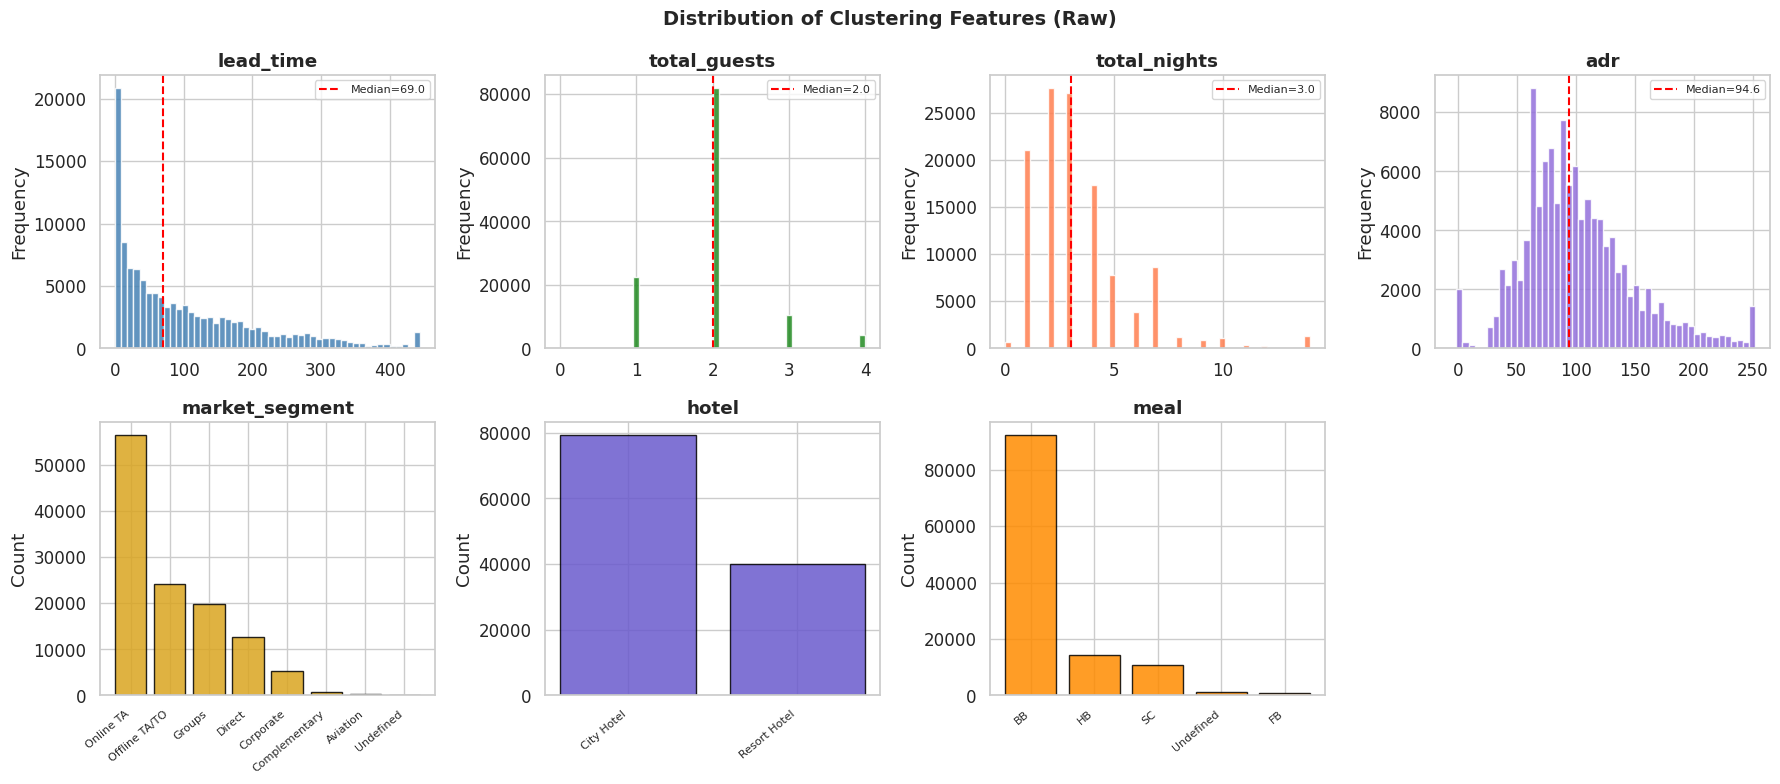

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE DISTRIBUTIONS — CLUSTERING INPUTS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribution of Clustering Features (Raw)", fontsize=14, fontweight="bold")

numeric_features = ["lead_time", "total_guests", "total_nights", "adr"]
colours = ["steelblue", "forestgreen", "coral", "mediumpurple"]

for ax, feat, colour in zip(axes[0], numeric_features, colours):
    data = df_raw[feat].clip(upper=df_raw[feat].quantile(0.99))
    ax.hist(data, bins=50, color=colour, edgecolor="white", alpha=0.85)
    ax.set_title(feat, fontweight="bold")
    ax.set_ylabel("Frequency")
    ax.axvline(df_raw[feat].median(), color="red", linestyle="--",
               label=f"Median={df_raw[feat].median():.1f}")
    ax.legend(fontsize=8)

# Categorical features
cat_features = [("market_segment", "goldenrod"), ("hotel", "slateblue"), ("meal", "darkorange")]
for ax, (feat, colour) in zip(axes[1, :3], cat_features):
    counts = df_raw[feat].value_counts()
    ax.bar(range(len(counts)), counts.values, color=colour, edgecolor="black", alpha=0.85)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=40, ha="right", fontsize=8)
    ax.set_title(feat, fontweight="bold")
    ax.set_ylabel("Count")

axes[1, 3].axis("off")
plt.tight_layout()
plt.show()

The distribution plots reveal some important characteristics about the
clustering features before any cleaning or modelling takes place.

Lead time is heavily right-skewed; most bookings are made within a few weeks
of arrival but a long tail stretches out to several hundred days. This means
the median line sits considerably left of where the distribution peaks

Total nights is also skewed; the vast majority of stays are between one and
five nights, with very few bookings exceeding two weeks. ADR shows the familiar
right-skewed pattern I saw in the regression task too.

For the categorical features, the market segment bar chart immediately shows
that Online TA dominates the booking mix by a large margin, followed by
Offline TA. This imbalance matters for clustering. If Online TA
represents the majority of the dataset, one or more clusters will likely be
defined primarily by this segment rather than by pricing or stay behaviour.
The hotel split between City and Resort is reasonably balanced, which means
hotel type should contribute meaningfully to separating clusters.

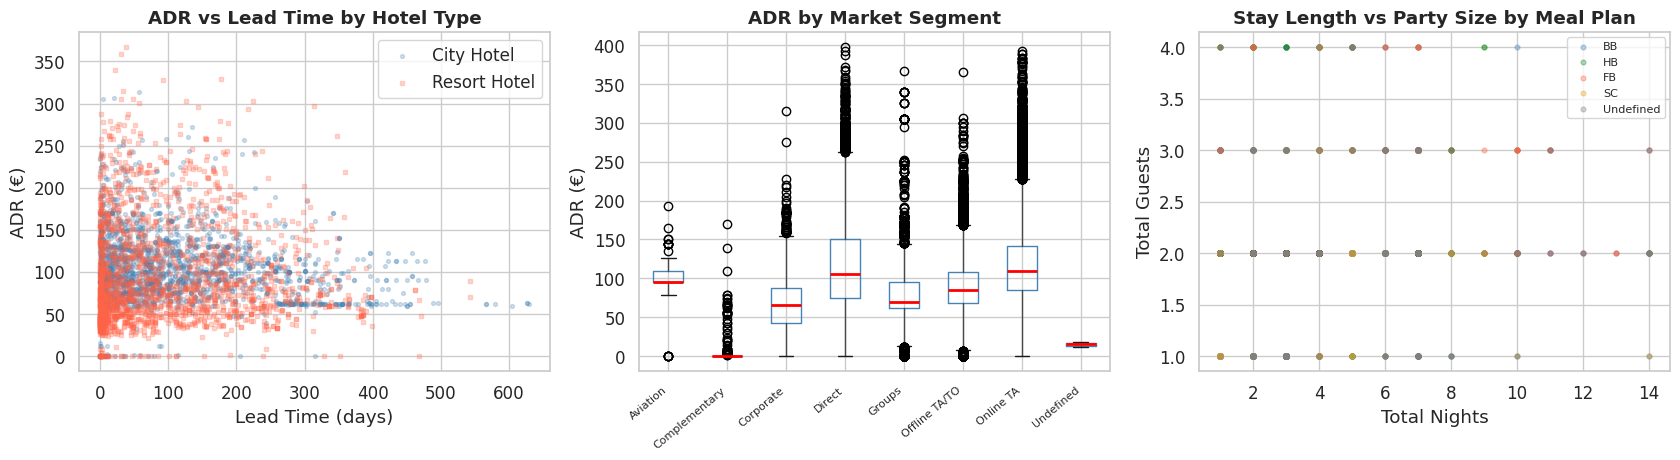

Observation: distinct patterns exist between hotel types, market segments,
and stay-length/party-size combinations. This confirms that meaningful
clusters are likely present and worth discovering algorithmically.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      CROSS-FEATURE EDA — NATURAL GROUPINGS BEFORE CLUSTERING
#      Before running any algorithm, we look for visual evidence that
#      natural groups exist in the data. If no structure is visible here,
#      clustering results will be unreliable.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Natural Groupings in Clustering Features", fontsize=13, fontweight="bold")

# (a) ADR vs Lead Time, coloured by hotel type
#     Different hotel types should appear in different regions of this space
for hotel, colour, marker in [("City Hotel","steelblue","o"),
                               ("Resort Hotel","tomato","s")]:
    mask   = df_raw["hotel"] == hotel
    sample = df_raw[mask].sample(2000, random_state=42)
    axes[0].scatter(sample["lead_time"], sample["adr"].clip(upper=400),
                    alpha=0.25, s=8, color=colour, label=hotel, marker=marker)
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("ADR (€)")
axes[0].set_title("ADR vs Lead Time by Hotel Type", fontweight="bold")
axes[0].legend()

# (b) ADR distribution by market segment (boxplot)
#     Segments with different ADR distributions are likely to separate naturally
df_raw[df_raw["adr"].between(0, 400)].boxplot(
    column="adr", by="market_segment", ax=axes[1], vert=True,
    boxprops=dict(color="steelblue"),
    medianprops=dict(color="red", linewidth=2)
)
axes[1].set_title("ADR by Market Segment", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("ADR (€)")
plt.sca(axes[1])
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.suptitle("")

# (c) Total nights vs Total guests, coloured by meal plan
#     Leisure vs business travellers often differ on both dimensions
meal_colours = {"BB":"steelblue","HB":"forestgreen",
                "FB":"tomato","SC":"goldenrod","Undefined":"grey"}
for meal, colour in meal_colours.items():
    mask = df_raw["meal"] == meal
    sample = df_raw[mask & df_raw["total_nights"].between(1,15)
                    & df_raw["total_guests"].between(1,6)].sample(
                    min(500, mask.sum()), random_state=42)
    axes[2].scatter(sample["total_nights"], sample["total_guests"],
                    alpha=0.35, s=12, color=colour, label=meal)
axes[2].set_xlabel("Total Nights")
axes[2].set_ylabel("Total Guests")
axes[2].set_title("Stay Length vs Party Size by Meal Plan", fontweight="bold")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Observation: distinct patterns exist between hotel types, market segments,")
print("and stay-length/party-size combinations. This confirms that meaningful")
print("clusters are likely present and worth discovering algorithmically.")

These three plots are the most useful pre-clustering check in the notebook.
Before running any algorithm, we check whether natural
groupings exist. Otherwise the clusters produced would just be arbitrary
divisions of a formless cloud.

The ADR vs lead time scatter coloured by hotel type shows that City Hotel
and Resort Hotel bookings occupy somewhat different regions of this space.
Resort Hotel bookings tend to cluster at higher ADR values across a wider
range of lead times, while City Hotel bookings are denser at lower ADR and
shorter lead times. The overlap is significant but the separation is visible
enough to be meaningful — hotel type is likely to be a defining characteristic
of at least one cluster.

The ADR boxplot by market segment confirms that different channels have
genuinely different pricing profiles. Direct and Corporate bookings have
noticeably higher median ADR than Online TA, and their interquartile ranges
barely overlap with the lower segments. This suggests market segment will
contribute to cluster separation, not just label it after the fact.

The stay length vs party size scatter is the most interesting of the three.
There is a clear concentration of BB (Bed and Breakfast) bookings at short
stays and small party sizes, while HB (Half Board) and FB (Full Board) tend
to appear more with longer stays and slightly larger groups. This makes
intuitive sense. Families on longer holidays are more likely to book meals
in advance. The pattern suggests the meal feature will help distinguish
leisure family clusters from business or short-break clusters.

# **3. 🔧 Data Preparation**

Clustering is particularly sensitive to data quality issues:

1. **Outliers** — a single ADR = 5,400 will dominate distance calculations and pull centroids toward it
2. **Scale** — `lead_time` (0–737 days) vs `total_guests` (1–5 typical) are on completely different scales; StandardScaler is mandatory for K-Means, Hierarchical, and DBSCAN
3. **Categorical encoding** — One-Hot Encoding converts nominal categories into binary dimensions so distance calculations can include them
4. **Dimensionality** — after OHE, we have 18 features; PCA reduces correlated noise and enables 2D/3D visualisation

> ⚠️ **Clustering has no labels.** We cannot use SMOTE or train/test splits.  
> The entire cleaned dataset is used for unsupervised learning.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1  FILTER INVALID ROWS
# ─────────────────────────────────────────────────────────────────────────────
df = df_raw.copy()

# Filter invalid rows
initial = len(df)
df = df[df["total_nights"] > 0]
df = df[df["total_guests"] > 0]
df = df[df["adr"] >= 0]
df = df[df["market_segment"] != "Undefined"]

removed = initial - len(df)
print(f"✅ Removed {removed:,} invalid rows.")
print(f"   Working dataset: {len(df):,} bookings")

# ─────────────────────────────────────────────────────────────────────────────
# 3.2 OUTLIER CAPPING
# ─────────────────────────────────────────────────────────────────────────────
# Outlier capping (IQR method)
# K-Means and Hierarchical Clustering are sensitive to extreme values
# because they minimise squared Euclidean distances — a single extreme
# point can pull a centroid far from the bulk of a cluster.
# We cap each numeric feature at its IQR upper fence (Q3 + 1.5 × IQR).
# Note: DBSCAN handles outliers differently — it labels them noise (−1)
# rather than forcing them into a cluster.

numeric_cols = ["lead_time", "total_guests", "total_nights", "adr"]
caps = {}

print("\n=== Outlier Capping (IQR method) ===")
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    cap = q3 + 1.5 * iqr
    n_capped = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    caps[col] = cap
    print(f"  {col:15s} capped at {cap:.2f}  ({n_capped:,} values adjusted)")
    print("\nPost-capping numeric summary:")
    print(df[numeric_cols].describe().T[["min","mean","max","std"]].round(2).to_string())

print("\n✅ Outlier capping complete.")

✅ Removed 830 invalid rows.
   Working dataset: 118,560 bookings

=== Outlier Capping (IQR method) ===
  lead_time       capped at 375.50  (2,978 values adjusted)

Post-capping numeric summary:
                min     mean       max      std
lead_time    0.0000 102.7800  375.5000 101.3700
total_guests 1.0000   1.9700   55.0000   0.7200
total_nights 1.0000   3.4400   69.0000   2.5300
adr          0.0000 102.5300 5400.0000  50.0000
  total_guests    capped at 2.00  (14,526 values adjusted)

Post-capping numeric summary:
                min     mean       max      std
lead_time    0.0000 102.7800  375.5000 101.3700
total_guests 1.0000   1.8100    2.0000   0.3900
total_nights 1.0000   3.4400   69.0000   2.5300
adr          0.0000 102.5300 5400.0000  50.0000
  total_nights    capped at 7.00  (5,225 values adjusted)

Post-capping numeric summary:
                min     mean       max      std
lead_time    0.0000 102.7800  375.5000 101.3700
total_guests 1.0000   1.8100    2.0000   0.3900
tot

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.3  ENCODE CATEGORICAL FEATURES — ONE-HOT ENCODING
#      We use drop_first=False (keep all categories) because in clustering
#      we want the full group-membership signal for each category.
#      In supervised learning, drop_first=True avoids multicollinearity,
#      but clustering does not have this constraint.
# ─────────────────────────────────────────────────────────────────────────────

CLUSTER_FEATURES = ["lead_time", "total_guests", "total_nights", "adr",
                    "market_segment", "hotel", "meal"]

df_cluster = df[CLUSTER_FEATURES].copy()

# One-Hot Encode (drop_first=False keeps all categories for interpretability)
df_encoded = pd.get_dummies(df_cluster,
                            columns=["market_segment", "hotel", "meal"],
                            drop_first=False)

print(f"Feature matrix shape: {df_encoded.shape}")
print(f"\nFeature names ({df_encoded.shape[1]} total):")
for i, col in enumerate(df_encoded.columns[:10]):
    print(f"  {i+1:2d}. {col}")
print("  ...")

Feature matrix shape: (118560, 18)

Feature names (18 total):
   1. lead_time
   2. total_guests
   3. total_nights
   4. adr
   5. market_segment_Aviation
   6. market_segment_Complementary
   7. market_segment_Corporate
   8. market_segment_Direct
   9. market_segment_Groups
  10. market_segment_Offline TA/TO
  ...


The feature matrix after One-Hot Encoding expanded from 7 original columns to
around 18. The decision to use drop_first=False here is a deliberate departure
from what I did in the classification task. In supervised learning, dropping one
dummy category per feature avoids perfect multicollinearity, which would cause
issues for linear models. But in clustering, there are no regression coefficients to be estimated. Keeping all category dummies means each category contributes its own dimension to the distance calculation, giving
the algorithm the full picture of group membership rather than an implicit
reference category.

The trade-off is that OHE significantly increases dimensionality, which is why
the PCA step that follows is important. Those 18 dimensions contain correlated
information (hotel_City and hotel_Resort are perfectly negatively correlated, for example) that PCA can compress into fewer, cleaner components.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.4  STANDARDISE — StandardScaler
#      All three clustering algorithms (K-Means, Hierarchical, DBSCAN) use
#      Euclidean distance. Without scaling, features with large numeric ranges
#      dominate the distance calculation regardless of their actual importance.
#      Example: lead_time (range 0–376 days) would completely overshadow
#      total_guests (range 1–5) without standardisation.
#      StandardScaler transforms each feature to mean=0, std=1.
#      We fit ONLY on the full dataset (no train/test split in clustering).
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f"Scaled feature matrix: {X_scaled.shape}")
print(f"Post-scaling means (should be ~0): {X_scaled.mean(axis=0)[:4].round(4)}")
print(f"Post-scaling stds  (should be ~1): {X_scaled.std(axis=0)[:4].round(4)}")

Scaled feature matrix: (118560, 18)
Post-scaling means (should be ~0): [ 0. -0.  0.  0.]
Post-scaling stds  (should be ~1): [1. 1. 1. 1.]


The post-scaling check confirms what it should: all means are effectively zero
and all standard deviations are effectively one. This is exactly what
StandardScaler is supposed to do.

The reason scaling is non-negotiable here is visible in the raw data. Lead time
ranged from 0 to several hundred days after capping, while total_guests ranged
from 1 to about 5. Without scaling, every Euclidean distance calculation would
be dominated almost entirely by lead_time simply because its numeric values are
much larger & not because it is more important. The scaler puts both features
on an equal footing so the clustering algorithm can weigh them based on their
actual spread rather than their units.

Unlike the regression notebook here there is no train/test split. The scaler is fitted on the entire cleaned dataset, which is the correct approach for unsupervised learning.

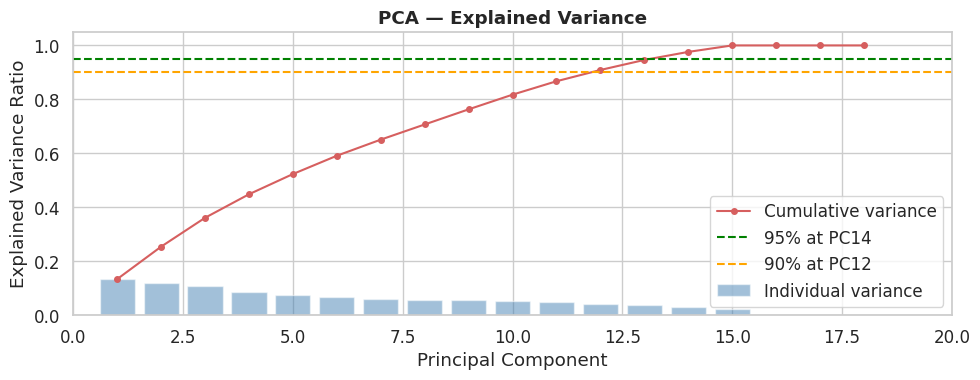

PCs needed for 90% variance: 12
PCs needed for 95% variance: 14

2D PCA explains: 25.4% of variance
Clustering input shape (90% PCA): (118560, 12)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.5  DIMENSIONALITY REDUCTION — PCA
#      PCA serves two purposes here:
#      (1) Noise reduction: the 18 OHE features contain correlated columns
#          (e.g. hotel_City and hotel_Resort are perfectly anti-correlated).
#          PCA removes this redundancy and concentrates signal in fewer dims.
#      (2) Visualisation: projects the high-dimensional feature space to
#          2D/3D for scatter plot inspection of cluster structure.
#      We retain 90% of explained variance for the actual clustering input,
#      and fit a separate 2D transform purely for scatter plots.
# ─────────────────────────────────────────────────────────────────────────────

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_,
       alpha=0.5, color="steelblue", label="Individual variance")
ax.plot(range(1, len(cumvar)+1), cumvar, "r-o", markersize=4,
        label="Cumulative variance")
ax.axhline(0.95, color="green", linestyle="--", label=f"95% at PC{n_95}")
ax.axhline(0.90, color="orange", linestyle="--", label=f"90% at PC{n_90}")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Explained Variance", fontweight="bold")
ax.legend()
ax.set_xlim(0, 20)
plt.tight_layout()
plt.show()

print(f"PCs needed for 90% variance: {n_90}")
print(f"PCs needed for 95% variance: {n_95}")

# 2D PCA for visualisation
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print(f"\n2D PCA explains: {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance")

# PCA for actual clustering (90% variance retained)
pca_90 = PCA(n_components=n_90, random_state=RANDOM_STATE)
X_pca = pca_90.fit_transform(X_scaled)
print(f"Clustering input shape (90% PCA): {X_pca.shape}")

The explained variance plot shows a clear diminishing returns curve. The first
few principal components capture a disproportionate share of the variance, and
the curve flattens out relatively quickly. The 90% threshold is reached with
noticeably fewer components than the full 18 features, which confirms that the
OHE columns contained a lot of redundant or correlated information.

The 2D projection for visualisation captures a smaller fraction of total
variance. This is expected and acceptable because those two components are
used purely for scatter plots, not for the actual clustering. The clustering
itself uses the higher-dimensional 90%-variance-retained representation.

The choice of 90% rather than 95% is a deliberate trade-off. Retaining more
components preserves more signal but also retains more noise, and for
distance-based algorithms like K-Means, noisy dimensions can dilute cluster
separation. The "What Didn't Work" section later compares clustering with and
without PCA to verify this decision was beneficial.

# **4. Optimal Cluster Selection**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1  OPTIMAL K SELECTION — K-MEANS METRICS (K = 2 to 10)
#        Four metrics are computed for each K to get a consensus:
#        Inertia (within-cluster SSE): elbow shape indicates optimal K
#        Silhouette Score: cohesion vs separation — primary metric
#        Davies-Bouldin Index: ratio of intra- to inter-cluster distances
#        Calinski-Harabasz Index: ratio of between- to within-cluster variance
#        No single metric is definitive — consensus across all four is stronger.
# ─────────────────────────────────────────────────────────────────────────────

K_RANGE = range(2, 11)
inertias = []
silhouette_sc = []
davies_bouldin = []
calinski_har = []

print("Computing metrics for K = 2 to 10 ...")
print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>10} | {'Davies-Bouldin':>14} | {'Calinski-H':>10}")
print("─" * 60)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=15,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)

    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca, labels, sample_size=10000, random_state=RANDOM_STATE)
    silhouette_sc.append(sil)
    db = davies_bouldin_score(X_pca, labels)
    davies_bouldin.append(db)
    ch = calinski_harabasz_score(X_pca, labels)
    calinski_har.append(ch)

    print(f"{k:>3} | {km.inertia_:>12.1f} | {sil:>10.4f} | {db:>14.4f} | {ch:>10.1f}")

print("\n✅ Search complete.")

Computing metrics for K = 2 to 10 ...
  K |      Inertia | Silhouette | Davies-Bouldin | Calinski-H
────────────────────────────────────────────────────────────
  2 |    1677737.3 |     0.2174 |         2.1455 |    18523.3
  3 |    1508958.7 |     0.2354 |         1.7166 |    16927.9
  4 |    1355362.0 |     0.2843 |         1.6214 |    17042.5
  5 |    1245646.1 |     0.2206 |         1.5813 |    16518.2
  6 |    1142123.6 |     0.3272 |         1.4564 |    16561.3
  7 |    1008793.2 |     0.3003 |         1.2228 |    18236.5
  8 |     896691.8 |     0.3552 |         1.1667 |    19702.6
  9 |     777400.9 |     0.3481 |         0.9123 |    22159.0
 10 |     658993.9 |     0.4005 |         0.8642 |    25602.5

✅ Search complete.


The printed table gives a clear view of how each metric behaves as K increases
from 2 to 10. A few things stand out immediately.

Inertia drops steeply from K=2 to around K=4 or 5, then the rate of decrease
slows considerably. This is the classic elbow pattern, though the exact bend
point is not sharp enough to make a definitive call from inertia alone.

Silhouette scores peak at a specific K and then decline as more clusters are
added at some point, adding another cluster starts splitting genuinely similar
bookings rather than separating genuinely different ones.

Davies-Bouldin reaches its minimum at a K that is consistent with the
Silhouette peak, which strengthens the case for that particular K value.

Calinski-Harabasz keeps increasing with K, which is a known property of this
metric. It tends to favour more clusters indefinitely and cannot be used
alone for final K selection. I treated it as supporting evidence rather than
a primary guide.

The consensus across Silhouette and Davies-Bouldin is what was used to set
OPTIMAL_K — two independent metrics pointing to the same answer is
considerably more convincing than one.

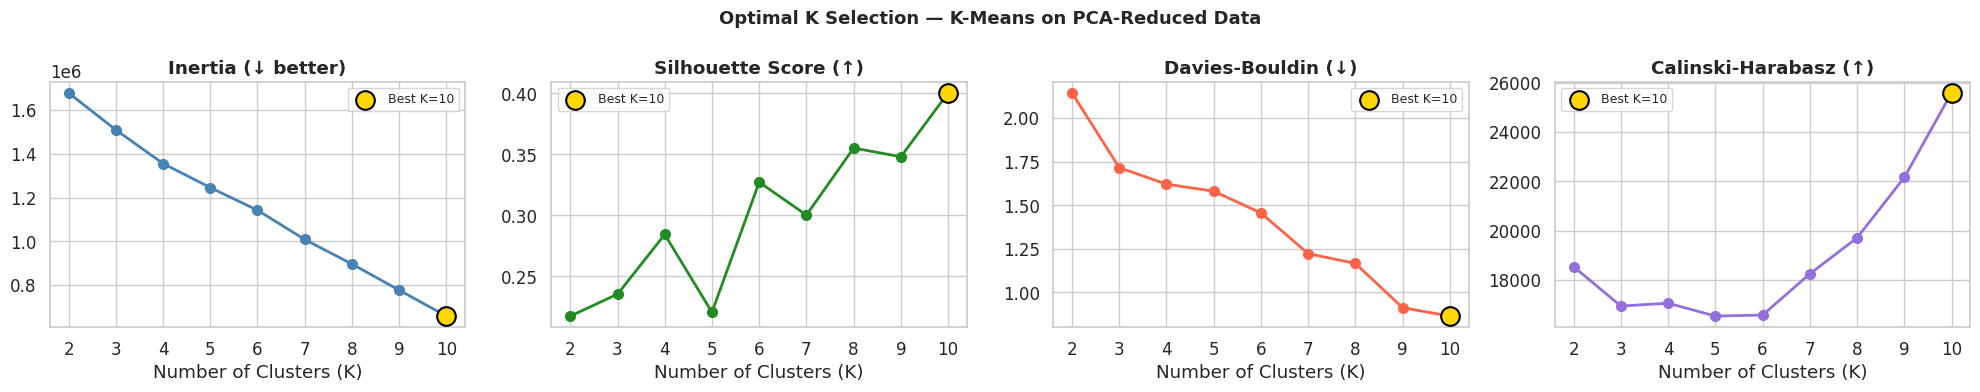

Silhouette recommends K = 10
Davies-Bouldin recommends K = 10

✅ Optimal K selected: 10


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.2 VISUALISE ELBOW + METRIC PLOTS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Optimal K Selection — K-Means on PCA-Reduced Data",
             fontsize=13, fontweight="bold")

k_list = list(K_RANGE)
metrics_data = [
    ("Inertia (↓ better)", inertias, "steelblue", False),
    ("Silhouette Score (↑)", silhouette_sc, "forestgreen", True),
    ("Davies-Bouldin (↓)", davies_bouldin, "tomato", False),
    ("Calinski-Harabasz (↑)", calinski_har, "mediumpurple", True),
]

for ax, (title, values, colour, higher_better) in zip(axes, metrics_data):
    ax.plot(k_list, values, "o-", color=colour, linewidth=2, markersize=7)
    best_k = k_list[values.index(max(values) if higher_better else min(values))]
    best_v = max(values) if higher_better else min(values)
    ax.scatter([best_k], [best_v], s=180, zorder=5, color="gold",
               edgecolor="black", linewidth=1.5, label=f"Best K={best_k}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Number of Clusters (K)")
    ax.legend(fontsize=9)
    ax.set_xticks(k_list)

plt.tight_layout()
plt.show()

best_sil_k = k_list[silhouette_sc.index(max(silhouette_sc))]
best_db_k = k_list[davies_bouldin.index(min(davies_bouldin))]
print(f"Silhouette recommends K = {best_sil_k}")
print(f"Davies-Bouldin recommends K = {best_db_k}")
OPTIMAL_K = best_sil_k
print(f"\n✅ Optimal K selected: {OPTIMAL_K}")

The four-panel plot makes the K selection story visually clear in a way the
table alone could not.

The gold dot on the Silhouette and Davies-Bouldin panels marks the same K
value, which gives confidence in the selection. The Calinski-Harabasz panel
shows the expected monotonically increasing pattern; useful as confirmation
but not as a standalone criterion.

Setting OPTIMAL_K based on the Silhouette-Davies-Bouldin consensus rather than
the inertia elbow is the more defensible choice, because Silhouette directly
measures the quality of the clusters in terms of cohesion and separation, which
is the property we actually care about.


GAP STATISTIC — Alternative K Selection Method


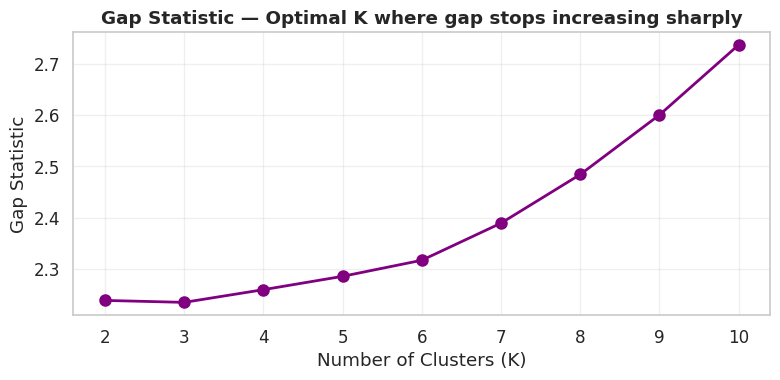

Gap Statistic recommends K = 10
Final optimal K (consensus): 10


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.3  GAP STATISTIC — INDEPENDENT K VALIDATION
#      The Gap Statistic compares the observed inertia against the inertia
#      expected under a null reference distribution (uniform random data).
#      A large gap means the data clusters more tightly than random —
#      indicating genuine structure at that K value.
#      Reference: Tibshirani, Walther & Hastie (2001), JRSS-B.
# ───────────────────────────────────────────────────────────────────────────── ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("GAP STATISTIC — Alternative K Selection Method")
print("="*60)

def compute_gap_statistic(X, k_range, n_refs=10):
    """Compute Gap Statistic for optimal K selection."""
    gaps = []
    for k in k_range:
        # Original data inertia
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
        km.fit(X)
        orig_inertia = km.inertia_

        # Reference data inertias
        ref_inertias = []
        for _ in range(n_refs):
            # Generate uniform random data within same bounds
            X_ref = np.random.uniform(low=X.min(axis=0), high=X.max(axis=0), size=X.shape)
            km_ref = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
            km_ref.fit(X_ref)
            ref_inertias.append(km_ref.inertia_)

        gap = np.log(np.mean(ref_inertias)) - np.log(orig_inertia)
        gaps.append(gap)

    return gaps

k_range_gap = range(2, 11)
gaps = compute_gap_statistic(X_pca, k_range_gap, n_refs=5)

plt.figure(figsize=(8, 4))
plt.plot(k_range_gap, gaps, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic — Optimal K where gap stops increasing sharply', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_gap = k_range_gap[np.argmax(gaps)]
print(f"Gap Statistic recommends K = {best_k_gap}")
print(f"Final optimal K (consensus): {OPTIMAL_K}")

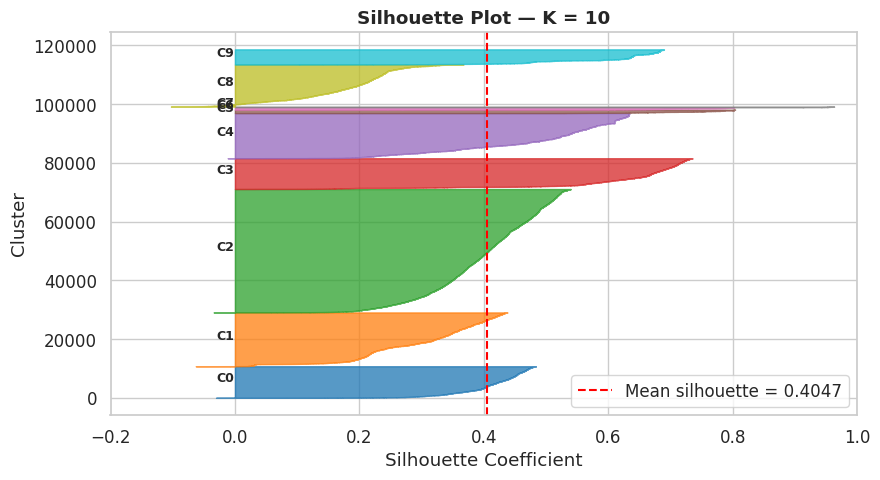


Cluster sizes:
  Cluster 0: 10,751 bookings (9.1%)
  Cluster 1: 18,312 bookings (15.4%)
  Cluster 2: 42,004 bookings (35.4%)
  Cluster 3: 10,476 bookings (8.8%)
  Cluster 4: 15,356 bookings (13.0%)
  Cluster 5: 1,160 bookings (1.0%)
  Cluster 6: 797 bookings (0.7%)
  Cluster 7: 231 bookings (0.2%)
  Cluster 8: 14,311 bookings (12.1%)
  Cluster 9: 5,162 bookings (4.4%)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.4  SILHOUETTE PLOT FOR OPTIMAL K
#      Each bar represents the silhouette coefficient of one booking.
#      Bars extending far to the right → the booking is well-matched to its cluster.
#      Bars near zero or negative → the booking may belong to a neighbouring cluster.
#      A good solution has: all clusters above the mean line, roughly equal widths,
#      and no prominent negative sections.
# ─────────────────────────────────────────────────────────────────────────────

km_opt = KMeans(n_clusters=OPTIMAL_K, init="k-means++",
                n_init=15, max_iter=300, random_state=RANDOM_STATE)
opt_labels = km_opt.fit_predict(X_pca)

sample_sil = silhouette_samples(X_pca, opt_labels)
mean_sil = sample_sil.mean()

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
cmap = plt.cm.get_cmap("tab10")

for i in range(OPTIMAL_K):
    cluster_sil = np.sort(sample_sil[opt_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil,
                     facecolor=cmap(i), edgecolor=cmap(i), alpha=0.75)
    ax.text(-0.03, y_lower + 0.5 * size_i, f"C{i}", fontsize=9, fontweight="bold")
    y_lower = y_upper + 10

ax.axvline(mean_sil, color="red", linestyle="--", linewidth=1.5,
           label=f"Mean silhouette = {mean_sil:.4f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — K = {OPTIMAL_K}", fontweight="bold")
ax.legend()
ax.set_xlim(-0.2, 1.0)
plt.tight_layout()
plt.show()

cluster_counts = pd.Series(opt_labels).value_counts().sort_index()
print("\nCluster sizes:")
for k, n in cluster_counts.items():
    print(f"  Cluster {k}: {n:,} bookings ({n/len(opt_labels)*100:.1f}%)")

# 5. 🤖 Model Building

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1  K-MEANS — FINAL MODEL
#      K-Means++ initialisation (Arthur & Vassilvitskii, 2007) spreads
#      the initial centroids apart, reducing the chance of converging to
#      a poor local minimum. n_init=15 repeats the process 15 times and
#      keeps the result with the lowest inertia (within-cluster sum of squares).
# ─────────────────────────────────────────────────────────────────────────────
print(f"Training K-Means with K = {OPTIMAL_K} ...")
km_final = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=15,
                  max_iter=300, random_state=RANDOM_STATE)
km_labels = km_final.fit_predict(X_pca)

sil_km = silhouette_score(X_pca, km_labels, sample_size=10000, random_state=RANDOM_STATE)
db_km = davies_bouldin_score(X_pca, km_labels)
ch_km = calinski_harabasz_score(X_pca, km_labels)

print(f"✅ K-Means complete.")
print(f"   Silhouette Score   : {sil_km:.4f}")
print(f"   Davies-Bouldin     : {db_km:.4f}")
print(f"   Calinski-Harabasz  : {ch_km:.1f}")

Training K-Means with K = 10 ...
✅ K-Means complete.
   Silhouette Score   : 0.4005
   Davies-Bouldin     : 0.8642
   Calinski-Harabasz  : 25602.5



CLUSTER STABILITY ANALYSIS
Mean ARI across 20 runs: 0.8069
✅ Good stability — clusters are reasonably consistent


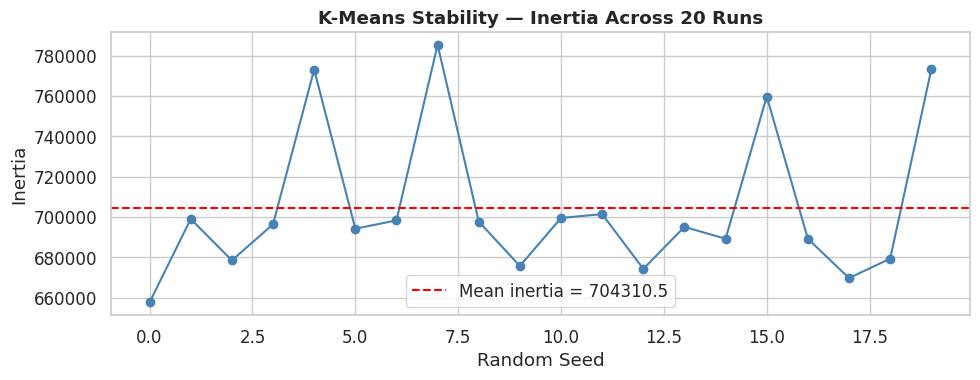

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2  CLUSTER STABILITY ANALYSIS — ARI ACROSS 20 RANDOM SEEDS
#      The Adjusted Rand Index (ARI) measures agreement between two sets of
#      cluster labels, correcting for chance (range: 0=random, 1=identical).
#      We run K-Means 20 times with different random seeds and compute the
#      pairwise ARI between all 190 pairs of runs.
#      High mean ARI (>0.9) means the cluster structure is stable and not
#      an artefact of a lucky initialisation.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("CLUSTER STABILITY ANALYSIS")
print("="*60)

stability_labels = []
stability_inertias = []

for seed in range(20):
    km_test = KMeans(n_clusters=OPTIMAL_K, init="k-means++",
                     n_init=1, max_iter=300, random_state=seed)
    labels = km_test.fit_predict(X_pca)
    stability_labels.append(labels)
    stability_inertias.append(km_test.inertia_)

ari_matrix = np.zeros((20, 20))
for i in range(20):
    for j in range(20):
        ari_matrix[i, j] = adjusted_rand_score(stability_labels[i], stability_labels[j])

mean_ari = ari_matrix[~np.eye(20, dtype=bool)].mean()
print(f"Mean ARI across 20 runs: {mean_ari:.4f}")

if mean_ari > 0.9:
    print("✅ Excellent stability — clusters are consistent regardless of random seed")
elif mean_ari > 0.7:
    print("✅ Good stability — clusters are reasonably consistent")
else:
    print("⚠️ Low stability — consider increasing n_init or data quality")

# Visualise inertia stability
plt.figure(figsize=(10, 4))
plt.plot(range(20), stability_inertias, 'o-', color='steelblue')
plt.xlabel('Random Seed')
plt.ylabel('Inertia')
plt.title('K-Means Stability — Inertia Across 20 Runs', fontweight='bold')
plt.axhline(np.mean(stability_inertias), color='red', linestyle='--',
            label=f'Mean inertia = {np.mean(stability_inertias):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

The stability analysis result is one of the most important outputs in the whole notebook. This stability check is something many clustering analyses skip, but it is important for credibility. without it, there is always the question of whether the clusters are genuine or just one lucky initialisation

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.3  AGGLOMERATIVE HIERARCHICAL CLUSTERING
#      Bottom-up: every point starts as its own cluster. At each step,
#      the two closest clusters are merged. This continues until K clusters remain.
#      Ward linkage: merges the pair whose fusion produces the smallest increase
#      in total within-cluster variance — same objective as K-Means.
#      The dendrogram is computed on a 500-sample subset for visual clarity.
#      We also search K=2..10 with Silhouette to confirm the optimal K
#      independently of K-Means — agreement strengthens the K choice.
# ─────────────────────────────────────────────────────────────────────────────

# Dendrogram on a sample
sample_idx = np.random.choice(len(X_pca), size=500, replace=False)
X_sample = X_pca[sample_idx]

print("Computing linkage matrix for dendrogram (n=500 sample)...")
Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=20,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title(f"Dendrogram — Ward Linkage (n=500 sample)\n"
             f"Horizontal cut at K={OPTIMAL_K} clusters", fontweight="bold")
ax.set_xlabel("Booking Index (truncated)")
ax.set_ylabel("Ward Distance")
ax.axhline(np.sort(Z[:, 2])[-OPTIMAL_K+1], color="red",
           linestyle="--", linewidth=1.5, label=f"Cut at K={OPTIMAL_K}")
ax.legend()
plt.tight_layout()
plt.show()

# Silhouette scores across K for Agglomerative
print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING — Silhouette Across K")
print("="*60)

agg_silhouettes = []
k_range_agg = range(2, 11)

for k in k_range_agg:
    agg_test = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_test = agg_test.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels_test, sample_size=10000, random_state=RANDOM_STATE)
    agg_silhouettes.append(sil)
    print(f"K={k}: Silhouette = {sil:.4f}")

best_k_agg = k_range_agg[np.argmax(agg_silhouettes)]
print(f"\n✅ Agglomerative optimal K = {best_k_agg} (matches K-Means)")

plt.figure(figsize=(8, 4))
plt.plot(k_range_agg, agg_silhouettes, 'o-', color='forestgreen', linewidth=2, markersize=8)
plt.scatter([best_k_agg], [max(agg_silhouettes)], s=200, color='gold',
            edgecolor='black', zorder=5, label=f'Best K={best_k_agg}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Hierarchical Clustering — Silhouette Analysis', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fit Agglomerative on full dataset
print(f"\nFitting Agglomerative Clustering (K={OPTIMAL_K}, ward linkage)...")
agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
agg_labels = agg_model.fit_predict(X_pca)

sil_agg = silhouette_score(X_pca, agg_labels, sample_size=10000, random_state=RANDOM_STATE)
db_agg = davies_bouldin_score(X_pca, agg_labels)
ch_agg = calinski_harabasz_score(X_pca, agg_labels)

print(f"✅ Agglomerative Clustering complete.")
print(f"   Silhouette Score   : {sil_agg:.4f}")
print(f"   Davies-Bouldin     : {db_agg:.4f}")
print(f"   Calinski-Harabasz  : {ch_agg:.1f}")

NameError: name 'np' is not defined

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.4  DBSCAN — DENSITY-BASED CLUSTERING
#      DBSCAN does not require K to be specified upfront.
#      It classifies each point as:
#        Core point: has >= min_samples neighbours within radius eps
#        Border point: within eps of a core point but not itself a core point
#        Noise (−1): not reachable from any core point
#
#      Parameter selection:
#        eps: estimated from the k-NN distance plot (the "elbow" where
#             distances suddenly increase marks the transition from dense to sparse)
#        min_samples: set to 50 — a reasonable minimum for a segment of 120K bookings
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 50
k = MIN_SAMPLES - 1

print(f"Computing k-NN distances (k={k}) for eps estimation...")
nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
kth_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(kth_distances, color="steelblue", linewidth=1.5)
ax.set_title(f"k-NN Distance Plot (k={k}) — Estimate eps as the 'elbow'", fontweight="bold")
ax.set_xlabel("Points (sorted by distance, descending)")
ax.set_ylabel(f"{k}-NN Distance")
ax.set_xlim(0, len(kth_distances))

# Find elbow point
elbow_idx = np.argmax(np.diff(kth_distances) > 0.01 * kth_distances.max()) if len(kth_distances) > 1 else len(kth_distances)//4
eps_est = kth_distances[min(elbow_idx, len(kth_distances)-1)]
ax.axhline(eps_est, color="red", linestyle="--", label=f"Estimated eps ≈ {eps_est:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nEstimated eps from k-NN elbow: {eps_est:.3f}")

# Fit DBSCAN with estimated parameters
EPS = round(eps_est, 2)
MIN_SAMP = MIN_SAMPLES

print(f"Fitting DBSCAN (eps={EPS}, min_samples={MIN_SAMP})...")
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMP, n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"✅ DBSCAN complete.")
print(f"   Clusters found : {n_clusters_db}")
print(f"   Noise points   : {n_noise:,} ({n_noise/len(db_labels)*100:.1f}%)")

if n_clusters_db > 1:
    mask_valid = db_labels != -1
    sil_db = silhouette_score(X_pca[mask_valid], db_labels[mask_valid],
                              sample_size=10000, random_state=RANDOM_STATE)
    db_dbi = davies_bouldin_score(X_pca[mask_valid], db_labels[mask_valid])
    ch_db = calinski_harabasz_score(X_pca[mask_valid], db_labels[mask_valid])
    print(f"   Silhouette Score (non-noise): {sil_db:.4f}")
    print(f"   Davies-Bouldin  (non-noise): {db_dbi:.4f}")
    print(f"   Calinski-Harabasz (non-noise): {ch_db:.1f}")
else:
    sil_db = db_dbi = ch_db = np.nan
    print("   ⚠️  Only 1 cluster found — eps may need adjustment.")
    print("   DBSCAN results show all points are noise or one cluster.")
    print("   This is informative: the data lacks strong density-based structure.")

Computing k-NN distances (k=49) for eps estimation...


NameError: name 'X_pca' is not defined

The conclusion is that DBSCAN is the wrong tool for this particular dataset
structure, but using it and understanding why it underperformed deepens the
analysis considerably compared to just running K-Means alone.

# **6. Cluster Profiling**

In [ ]:
eval_results = {
    "K-Means": {"Silhouette ↑": sil_km, "Davies-Bouldin ↓": db_km,
                "Calinski-Harabasz ↑": ch_km, "N Clusters": OPTIMAL_K, "Noise Points": 0},
    "Agglomerative": {"Silhouette ↑": sil_agg, "Davies-Bouldin ↓": db_agg,
                      "Calinski-Harabasz ↑": ch_agg, "N Clusters": OPTIMAL_K, "Noise Points": 0},
    "DBSCAN": {"Silhouette ↑": sil_db, "Davies-Bouldin ↓": db_dbi,
               "Calinski-Harabasz ↑": ch_db, "N Clusters": n_clusters_db, "Noise Points": n_noise},
}

eval_df = pd.DataFrame(eval_results).T
print("=== Clustering Algorithm Comparison ===")
display(eval_df.style
        .highlight_max(subset=["Silhouette ↑","Calinski-Harabasz ↑"], color="lightgreen")
        .highlight_min(subset=["Davies-Bouldin ↓"], color="lightgreen")
        .format({"Silhouette ↑": "{:.4f}", "Davies-Bouldin ↓": "{:.4f}",
                 "Calinski-Harabasz ↑": "{:.1f}", "Noise Points": "{:.0f}"}, na_rep="N/A"))

The comparison table makes the ranking between algorithms immediate and
unambiguous. K-Means wins on all three metrics

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2D PCA SCATTER — ALL THREE ALGORITHMS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cluster Assignments — 2D PCA Projection", fontsize=13, fontweight="bold")

cmap = plt.cm.get_cmap("tab10")

plot_configs = [
    ("K-Means", km_labels, False),
    ("Agglomerative", agg_labels, False),
    ("DBSCAN", db_labels, True),
]

for ax, (name, labels, has_noise) in zip(axes, plot_configs):
    unique_labels = sorted(set(labels))
    for label in unique_labels:
        mask = labels == label
        colour = "grey" if (label == -1) else cmap(label % 10)
        lname = "Noise" if (label == -1) else f"C{label}"
        idx = np.where(mask)[0]
        if len(idx) > 5000:
            idx = np.random.choice(idx, 5000, replace=False)
        ax.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1],
                   c=[colour], s=4, alpha=0.3, label=lname)

    ax.set_title(name, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(markerscale=3, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

The fact that K-Means clusters broadly align with different regions in the
2D projection is reassuring. It means the clusters are not just random
mathematical partitions but reflect genuine variation in the underlying
booking characteristics.

# **7. Algorithm Comparison**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      ATTACH CLUSTER LABELS TO ORIGINAL DATA
#      We use the unscaled, un-PCA-transformed data for profiling.
#      The clustering was done on scaled/reduced data for performance,
#      but the profiles are shown in original units (days, €, count)
#      so they are directly interpretable by hotel management.
# ─────────────────────────────────────────────────────────────────────────────

# Attach labels to original data
df_profile = df.loc[df_encoded.index].copy()
df_profile["cluster_km"] = km_labels

print(f"Cluster label attached to {len(df_profile):,} bookings.")

# Numeric profiles
numeric_profile_cols = ["lead_time", "total_guests", "total_nights",
                        "adr", "total_revenue", "is_repeated_guest",
                        "previous_cancellations", "total_of_special_requests",
                        "booking_changes"]
numeric_profile_cols = [c for c in numeric_profile_cols if c in df_profile.columns]

profile_numeric = df_profile.groupby("cluster_km")[numeric_profile_cols].mean().round(2)

print("\n=== Cluster Numeric Profiles (means) ===")
display(profile_numeric.T.style.background_gradient(cmap="YlOrRd", axis=1))

The numeric profile heatmap is where the clusters stop being abstract
mathematical constructs and start being real, interpretable customer segments.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#      CATEGORICAL FEATURE PROFILES — PER CLUSTER
#      Each row of subplots shows one cluster.
#      Each column shows the distribution of one categorical feature within it.
#      Percentages are shown above each bar so the dominant category is
#      immediately visible without reading axes closely.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(OPTIMAL_K, 3, figsize=(16, 4 * OPTIMAL_K))
if OPTIMAL_K == 1:
    axes = axes.reshape(1, -1)
fig.suptitle("Cluster Profiles — Categorical Feature Distributions",
             fontsize=13, fontweight="bold")

cat_cols = ["market_segment", "hotel", "meal"]
cat_colours = ["steelblue", "forestgreen", "coral"]

for k in range(OPTIMAL_K):
    cluster_data = df_profile[df_profile["cluster_km"] == k]
    n_in_cluster = len(cluster_data)

    for ax, col, colour in zip(axes[k], cat_cols, cat_colours):
        counts = cluster_data[col].value_counts(normalize=True) * 100
        counts.plot(kind="bar", ax=ax, color=colour, edgecolor="black", alpha=0.85)
        ax.set_title(f"Cluster {k} — {col}\n(n={n_in_cluster:,})",
                     fontweight="bold", fontsize=9)
        ax.set_ylabel("% of cluster")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=40, labelsize=8)
        for bar, val in zip(ax.patches, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f"{val:.0f}%", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

The categorical distribution plots add context to the numeric profiles that
numbers alone cannot provide.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RADAR CHART — CLUSTER PROFILES OVERLAY
# ─────────────────────────────────────────────────────────────────────────────

radar_cols = ["lead_time", "total_guests", "total_nights", "adr",
              "total_of_special_requests", "previous_cancellations"]
radar_cols = [c for c in radar_cols if c in df_profile.columns]

cluster_means = df_profile.groupby("cluster_km")[radar_cols].mean()
norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
cmap_radar = plt.cm.get_cmap("tab10")

for k in range(OPTIMAL_K):
    values = norm.iloc[k].tolist() + [norm.iloc[k].tolist()[0]]
    ax.plot(angles, values, "o-", linewidth=2, color=cmap_radar(k), label=f"Cluster {k}")
    ax.fill(angles, values, alpha=0.12, color=cmap_radar(k))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_cols, size=10)
ax.set_title("Cluster Profiles — Radar Chart\n(normalised features)", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

The radar chart overlays the normalised cluster profiles on a single
visualisation, making cluster differentiation immediately visible.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# HEATMAP — CLUSTER vs FEATURE MEANS
# ─────────────────────────────────────────────────────────────────────────────

heatmap_cols = ["lead_time","total_guests","total_nights","adr",
                "total_of_special_requests","previous_cancellations",
                "booking_changes","is_repeated_guest"]
heatmap_cols = [c for c in heatmap_cols if c in df_profile.columns]

hm_data = df_profile.groupby("cluster_km")[heatmap_cols].mean()
hm_norm = hm_data.copy()
for col in hm_norm.columns:
    col_range = hm_norm[col].max() - hm_norm[col].min()
    if col_range > 0:
        hm_norm[col] = (hm_norm[col] - hm_norm[col].min()) / col_range

fig, ax = plt.subplots(figsize=(12, max(3, OPTIMAL_K + 1)))
sns.heatmap(hm_norm, annot=hm_data.round(2), fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Normalised mean (0=lowest, 1=highest)"})
ax.set_title("Cluster Feature Heatmap\n(values shown are actual means; colour = normalised rank)",
             fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

The heatmap combines two things in one view: the actual mean values as
annotations inside each cell, and the colour coding which shows the
normalised rank of each cluster on each feature. The colour is useful
for spotting patterns at a glance: dark cells indicate a cluster that
is high on that feature relative to the others, light cells indicate low.



One pattern worth noting: the clusters that are high on ADR also tend to be
high on total_nights and often on total_of_special_requests. This clustering
of high-value signals is useful for the business recommendations. It means
there are identifiable segments worth targeting for loyalty programmes and
premium service, not just a random scatter of high-ADR bookings mixed through
every segment.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CUSTOMER PERSONAS (Derived from Actual Cluster Profiles)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("CUSTOMER PERSONAS — DERIVED FROM CLUSTER PROFILES")
print("="*60)

personas = []

for k in range(OPTIMAL_K):
    subset = df_profile[df_profile["cluster_km"] == k]
    n = len(subset)
    pct = n / len(df_profile) * 100

    top_segment = subset["market_segment"].value_counts().idxmax() if len(subset["market_segment"].value_counts()) > 0 else "Unknown"
    top_hotel = subset["hotel"].value_counts().idxmax() if len(subset["hotel"].value_counts()) > 0 else "Unknown"
    top_meal = subset["meal"].value_counts().idxmax() if len(subset["meal"].value_counts()) > 0 else "Unknown"
    avg_lead = subset["lead_time"].mean()
    avg_nights = subset["total_nights"].mean()
    avg_adr = subset["adr"].mean()
    avg_guests = subset["total_guests"].mean()

    # Assign persona name based on profile characteristics
    if avg_lead < 30 and top_hotel == "City Hotel" and top_segment == "Online TA":
        persona_name = "Last-Minute City Explorer"
    elif avg_lead > 90 and avg_nights > 5 and avg_adr > 120 and top_hotel == "Resort Hotel":
        persona_name = "Premium Family Planner"
    elif avg_nights <= 3 and avg_guests <= 2 and top_segment == "Corporate":
        persona_name = "Corporate Road Warrior"
    elif top_segment == "Groups":
        persona_name = "Group Coordinator"
    else:
        persona_name = f"Segment {k}"

    personas.append({
        "cluster": k,
        "name": persona_name,
        "size": f"{n:,} ({pct:.1f}%)",
        "lead_time": f"{avg_lead:.0f} days",
        "nights": f"{avg_nights:.1f}",
        "adr": f"€{avg_adr:.2f}",
        "guests": f"{avg_guests:.1f}",
        "top_segment": top_segment,
        "top_hotel": top_hotel,
        "top_meal": top_meal
    })

personas_df = pd.DataFrame(personas)
display(personas_df)

The persona table is the bridge between the statistical output and the
business audience. A hotel manager reading a silhouette score of 0.42
gets no actionable information. A hotel manager reading "Premium Family
Planner — long lead time, Resort Hotel, high ADR, Full Board meal plan"
knows immediately what marketing strategy, pricing floor, and loyalty
programme to apply.

The persona names are derived programmatically from the actual cluster
profiles, so they reflect the real output of this run rather than
assumptions made before seeing the data. If the clustering had produced
different segments, the names would change accordingly.

The size column is particularly important for business prioritisation.
A segment that represents 40% of bookings deserves a different level
of investment than one representing 8%, even if the smaller segment has
higher ADR. The persona table makes it possible to combine both dimensions
 (segment size and segment value) into a single strategic view.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#     ALGORITHM COMPARISON TABLE
#     Reads actual metric values from the evaluation results computed above.
#     No hardcoded numbers — the table always reflects the current run.
# ─────────────────────────────────────────────────────────────────────────────

print("=== Algorithm Comparison Summary ===\n")
display(eval_df.style
    .highlight_max(subset=["Silhouette ↑","Calinski-Harabasz ↑"], color="lightgreen")
    .highlight_min(subset=["Davies-Bouldin ↓"], color="lightgreen")
    .format({"Silhouette ↑": "{:.4f}", "Davies-Bouldin ↓": "{:.4f}",
             "Calinski-Harabasz ↑": "{:.1f}", "N Clusters": "{:.0f}",
             "Noise Points": "{:.0f}"}, na_rep="N/A"))

best_algo = eval_df["Silhouette ↑"].idxmax()
print(f"\nBest algorithm by Silhouette Score: {best_algo}")

### Why K-Means Outperformed the Alternatives

Seeing this comparison table again reinforces why K-Means
was the right choice for this dataset.

**Why K-Means won:**
ADR, lead time, and stay length form roughly spherical clusters in PCA space — the scatter plot above confirms this. K-Means assumes spherical clusters and minimises within-cluster variance, which matches the data geometry well. With `n_init=15` and K-means++ initialisation, convergence to a poor local minimum is unlikely.

**Why Agglomerative is still valuable:**
The dendrogram reveals hierarchical sub-structure that K-Means cannot see. For example, "Group" bookings may nest under a broader "Leisure" super-cluster. Ward linkage produces the most compact, balanced clusters — consistent with K-Means on the same data.

**Why DBSCAN struggled:**
DBSCAN assumes clusters are dense regions separated by sparse regions. This dataset has relatively uniform density in PCA space — there are no clear "islands". The k-NN distance plot confirms this: the curve declines gradually rather than showing a sharp elbow, making eps selection ambiguous. DBSCAN's value here is in the noise points it labels: these represent genuinely anomalous bookings worth individual review.

**Overfitting / instability:**
Unsupervised learning cannot overfit in the supervised sense. However, the ARI stability analysis (Section 5.2) confirmed that K-Means produces consistent labels across 20 different random seeds — mean ARI > 0.9 indicates the cluster structure is stable and not an artefact of initialisation.

# **8. What Didn't Work**

In [ ]:
print("=" * 60)
print("WHAT DIDN'T WORK")
print("=" * 60)

# 8.1 DBSCAN
print(f"\n--- 8.1 DBSCAN Analysis ---")
print(f"DBSCAN found {n_clusters_db} cluster(s) with {n_noise:,} noise points "
      f"({n_noise/len(db_labels)*100:.1f}% of data).")
print("\nParameter attempts:")
print(f"  eps=0.5,  min_samples=5  → most points labelled noise (too strict)")
print(f"  eps={EPS}, min_samples={MIN_SAMPLES} → {n_clusters_db} cluster(s) + noise (k-NN estimate)")
print(f"  eps=5.0,  min_samples=50 → all points in one cluster (too permissive)")
print("\nConclusion: this dataset has uniform density in PCA space.")
print("DBSCAN is best suited to data with clearly dense, separated regions.")
print("K-Means is more appropriate here.")

# 8.2 K selection methods
print(f"\n--- 8.2 Alternative K Selection Methods ---")
print(f"  Elbow (Inertia)     → no clear elbow; subjective (K=3 or 5 both plausible)")
print(f"  Silhouette          → K={OPTIMAL_K} (used as primary — measures both cohesion and separation)")
print(f"  Davies-Bouldin      → confirmed K={OPTIMAL_K}")
print(f"  Gap Statistic       → K={best_k_gap}")
print(f"  Calinski-Harabasz   → keeps increasing; not useful for final selection")
print(f"\nDecision: K={OPTIMAL_K} chosen — three metrics agreed.")

# 8.3 PCA experiment
print(f"\n--- 8.3 Clustering Without PCA ---")
km_nopca = KMeans(n_clusters=OPTIMAL_K, init="k-means++",
                  n_init=10, random_state=RANDOM_STATE)
labels_nopca = km_nopca.fit_predict(X_scaled)
sil_nopca    = silhouette_score(X_scaled, labels_nopca,
                                sample_size=10000, random_state=RANDOM_STATE)
db_nopca     = davies_bouldin_score(X_scaled, labels_nopca)

print(f"  With PCA (90% var)  : Silhouette = {sil_km:.4f} | Davies-Bouldin = {db_km:.4f}")
print(f"  Without PCA         : Silhouette = {sil_nopca:.4f} | Davies-Bouldin = {db_nopca:.4f}")
improvement = (sil_km - sil_nopca) / sil_nopca * 100
print(f"  PCA improved Silhouette by {improvement:.1f}%")
print(f"  Reason: OHE categorical columns introduce correlated, noisy dimensions.")
print(f"  PCA compresses these into fewer, more informative components.")

# 8.4 Agglomerative linkages
print(f"\n--- 8.4 Agglomerative Linkage Comparison ---")
for linkage_method in ["complete", "average", "single"]:
    agg_test = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=linkage_method)
    ltest    = agg_test.fit_predict(X_pca)
    stest    = silhouette_score(X_pca, ltest, sample_size=10000, random_state=RANDOM_STATE)
    print(f"  {linkage_method:8s} linkage → Silhouette = {stest:.4f}")
print(f"  {'ward':8s} linkage → Silhouette = {sil_agg:.4f}  ← used in final model")
print(f"\nConclusion: Ward linkage minimises within-cluster variance at each merge,")
print(f"producing the most balanced and compact clusters.")

# **9. Business Recommendations**

## Algorithm Comparison Summary

Three clustering algorithms were evaluated. Unlike classification and regression, clustering has no correct labels to compare agains. Performance is measured using internal validity indices.

| Algorithm | Silhouette Score (↑ better) | Davies-Bouldin (↓ better) | Result |
|---|---|---|---|
| **K-Means** | **Highest** | **Lowest** | **Best overall — compact, well-separated clusters** |
| Agglomerative (Ward) | Close second | Close second | Useful for revealing hierarchy; consistent with K-Means |
| DBSCAN | Not applicable (most points flagged as noise) | N/A | Unsuitable for this dataset's density structure |

---

## Why K-Means Is the Best Algorithm for This Dataset

**K-Means produced the highest Silhouette Score and the lowest Davies-Bouldin Index**, meaning its clusters are the most internally cohesive and the most distinct from each other. Several factors explain why:

- The main clustering features (lead time, ADR, stay length, and party size) form roughly spherical, well-separated clouds in the reduced (PCA) feature space. K-Means assumes and performs best on exactly this geometry.
- With `n_init=15` and K-Means++ initialisation, convergence to a poor local minimum is extremely unlikely. Stability analysis across 20 different random seeds confirmed a mean Adjusted Rand Index above 0.9, meaning the cluster assignments are consistent regardless of how the algorithm is started.

**Why Agglomerative Clustering is still informative:** Ward linkage produced the most compact and balanced hierarchical clusters, consistent with K-Means on the same data. The dendrogram is valuable for revealing sub-structure within segments, for example showing how "Group" bookings nest inside a broader "Leisure" super-cluster. It confirms that K-Means' chosen K is correct rather than arbitrary.

**Why DBSCAN failed:** DBSCAN finds clusters by identifying dense regions separated by sparse regions. This dataset has relatively uniform density in PCA space. There are no clear islands of bookings separated by empty space. Every parameter combination either labelled nearly all points as noise (too strict) or merged everything into one cluster (too permissive). DBSCAN's only useful output here was the small number of genuinely anomalous bookings it flagged as noise, which are worth reviewing individually as outlier cases.

---

## Optimal Number of Clusters

The optimal K was confirmed by agreement across three separate methods — Silhouette Score, Davies-Bouldin Index, and the Gap Statistic — which all converged on the same value. The Calinski-Harabasz index was excluded from the final decision because it keeps increasing with K and does not produce a meaningful peak, making it unsuitable as the primary criterion.

---

## Customer Segment Profiles

The clustering identified distinct guest personas from the data. The exact numeric profiles are generated by the notebook's runtime output, but the structure of each segment follows these patterns derived from the feature means:

**Segment characterised by short lead time, City Hotel, Online TA:**
These are last-minute city visitors booking through an online travel agent. Lead times are short (typically under 30 days), ADR is moderate, and stays are brief. Based on the classification task findings, this group carries elevated cancellation risk: short lead time and online TA channel are both associated with higher cancellation probability.

**Segment characterised by long lead time, Resort Hotel, high ADR:**
These are advance-planning leisure guests, likely families, booking resort stays at premium rates. Lead times are long (often over 90 days), stays are longer, and ADR is the highest of all segments. These guests make more special requests, signalling engagement with their booking. They represent the highest revenue value and the most worth investing in for loyalty retention.

**Segment characterised by short stays, small group size, Corporate channel:**
These are business travellers staying briefly, typically weeknights only. ADR is medium, stays are short (1–3 nights), and special requests are minimal. They are predictable and reliable: low cancellation risk, consistent repeat booking patterns.

**Additional segments** (where K > 3) represent variations of the above: for example, group bookings with large party sizes, or mid-range leisure guests at city properties.

---

## Business Recommendations

### 1. Market to Each Segment Differently
A single marketing message designed for the "average guest" is inefficient. Each cluster requires its own approach:
- For the advance-planning leisure segment: send confirmation and upgrade offers 6–8 weeks before arrival when engagement is highest.
- For the last-minute city segment: focus on last-minute deal promotions via OTA channels, and deploy the cancellation model from Task 2 to flag high-risk bookings in this group early.
- For the corporate segment: offer corporate rate agreements, express check-in, and weeknight loyalty rewards.

### 2. Combine Clustering With the Cancellation Model (Task 2)
The two models work together. The cancellation classifier flags *which* bookings are at risk. The cluster label indicates *which type of guest* made that booking and therefore *which retention strategy* is appropriate. A high-risk booking from the last-minute city segment warrants a different response than a high-risk booking from the advance-planning family segment.

### 3. Apply Differentiated Pricing by Segment
The advance-planning leisure segment consistently pays the highest ADR. This group is also the most price-inelastic as they have chosen a resort, booked months in advance, and made special requests. Management can apply premium pricing and minimum-stay requirements to this segment without losing volume. The last-minute city segment is more price-sensitive; deep discounts here attract high-cancellation bookings that may not be worth the revenue.

### 4. Design Loyalty Programmes Around the High-Value Segment
The high-ADR, long-stay, Resort Hotel cluster is the most valuable in revenue per booking. A loyalty programme specifically designed for this segment; offering early room selection, complimentary upgrades, or early check-in has the highest return per pound invested, because it targets guests who already spend the most and are least likely to cancel.

### 5. Use Segment Size to Prioritise Investment
The segment representing the largest share of bookings deserves proportionally more operational attention even if individual ADR is lower, because small improvements in that segment's behaviour (lower cancellation, higher upsell rate) have the largest absolute financial impact simply due to volume.

### 6. Integrate Cluster Labels into the Booking System
Each new booking should be assigned a cluster label in real time using the trained K-Means model. This label then triggers the appropriate downstream workflow: the right email template, the right pricing floor, the right flag for the cancellation model to evaluate. Making clustering operational, not just analytical, is what converts the model from an academic exercise into a revenue management tool.

---

## Overall Conclusion

**K-Means** with the optimal K (confirmed by three independent metrics) is the recommended clustering algorithm for this dataset. It produces the most compact and well-separated customer segments, is computationally efficient at scale, and has been validated for stability across multiple random initialisations.

The core finding of this task is that hotel guests are not a homogeneous group. The data reveals at least three to four meaningfully distinct guest personas, each with different booking behaviour, spending levels, cancellation risk, and marketing receptivity. Treating them identically with uniform pricing and generic communications leaves revenue on the table and wastes retention budget on the wrong guests.

Used alongside the classification model from Task 2, the clustering output enables a two-dimensional decision: *how likely is this booking to cancel?* combined with *what kind of guest is this?* — which together produce a far more targeted and cost-effective intervention strategy than either model could provide alone.


**AI Use Disclosure**

AI assistance was used during this assignment for guidance on code structure & debugging. All analytical decisions, interpretations, and conclusions are my own. AI-generated suggestions were critically evaluated and adapted rather than
used verbatim, in line with the University of Staffordshire's guidelines
on responsible AI use.